In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

Interpretasi

Kode ini digunakan untuk mengimpor seluruh pustaka yang dibutuhkan selama proses analisis data. Library Pandas dan NumPy digunakan untuk mengolah data, Matplotlib dan Seaborn digunakan untuk visualisasi data, sedangkan Scikit-Learn digunakan untuk preprocessing, pembagian data, pembangunan model regresi, dan evaluasi performa model.

In [29]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data (3).csv


Interpretasi

Kode ini digunakan untuk mengunggah dataset ke Google Colab sehingga dataset dapat dibaca dan diproses pada tahap selanjutnya.

In [30]:
df = pd.read_csv("data.csv")
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


Interpretasi

df.head() Perintah df.head() digunakan untuk menampilkan 5 data pertama pada dataset. Dari output terlihat bahwa dataset berisi informasi spesifikasi mobil seperti merek, model, tahun, tenaga mesin, transmisi, konsumsi bahan bakar, dan harga (MSRP). Variabel MSRP digunakan sebagai target yang akan diprediksi pada model regresi.

In [31]:
df.info()
df.describe()
df.shape
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='object')

Interpretasi

Berdasarkan hasil df.info(), dataset memiliki 11.914 data dan 16 kolom. Terdapat beberapa kolom yang masih memiliki data kosong (missing value), sehingga perlu dilakukan proses pembersihan data sebelum membangun model. Selain itu, hasil df.columns menunjukkan nama-nama kolom yang ada pada dataset. Pada penelitian ini, kolom MSRP digunakan sebagai target yang akan diprediksi, sedangkan kolom lainnya digunakan sebagai data masukan (fitur) untuk model regresi.

**MISSING** **VALUE**

In [32]:
df.isnull().sum()

,0
Make,0
Model,0
Year,0
Engine Fuel Type,3
Engine HP,69
Engine Cylinders,30
Transmission Type,0
Driven_Wheels,0
Number of Doors,6
Market Category,3742


Interpretasi:

Berdasarkan hasil pengecekan, masih terdapat beberapa missing value pada dataset, yaitu pada kolom Engine Fuel Type (3 data), Engine HP (69 data), Engine Cylinders (30 data), Number of Doors (6 data), dan Market Category (3.742 data). Oleh karena itu, dilakukan penanganan missing value menggunakan metode forward fill (ffill) agar data menjadi lengkap sebelum proses pemodelan.

In [34]:
df.ffill(inplace=True)

**EDA**

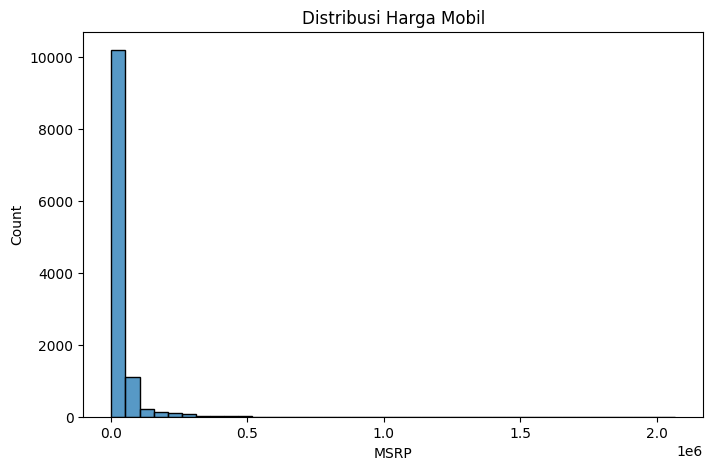

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(df["MSRP"], bins=40)
plt.title("Distribusi Harga Mobil")
plt.show()

Interpretasi:

Berdasarkan histogram, sebagian besar data berada pada rentang harga yang lebih rendah, sedangkan hanya sedikit mobil yang memiliki harga sangat tinggi. Hal ini menunjukkan bahwa distribusi harga mobil tidak merata dan miring ke kanan (right-skewed) karena terdapat beberapa mobil dengan harga yang jauh lebih mahal dibandingkan mayoritas data.

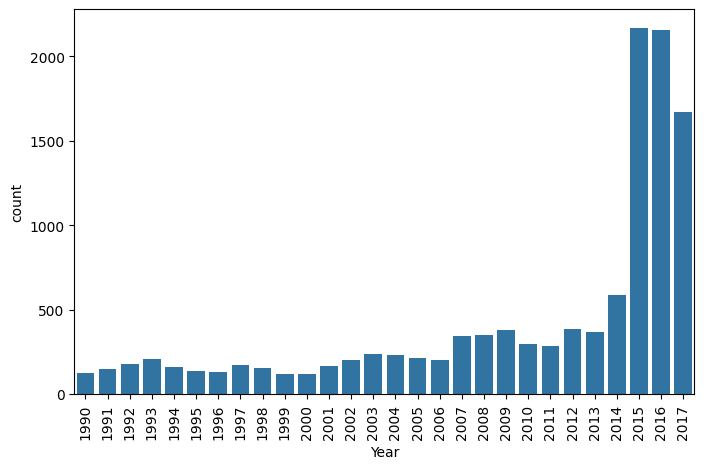

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(x="Year", data=df)
plt.xticks(rotation=90)
plt.show()

Interpretasi:

Grafik menunjukkan bahwa jumlah mobil dalam dataset tidak tersebar secara merata pada setiap tahun. Sebagian besar data berasal dari mobil keluaran tahun 2015–2017, sedangkan mobil dengan tahun produksi yang lebih lama jumlahnya lebih sedikit. Hal ini menunjukkan bahwa dataset didominasi oleh mobil dengan tahun produksi yang lebih baru.

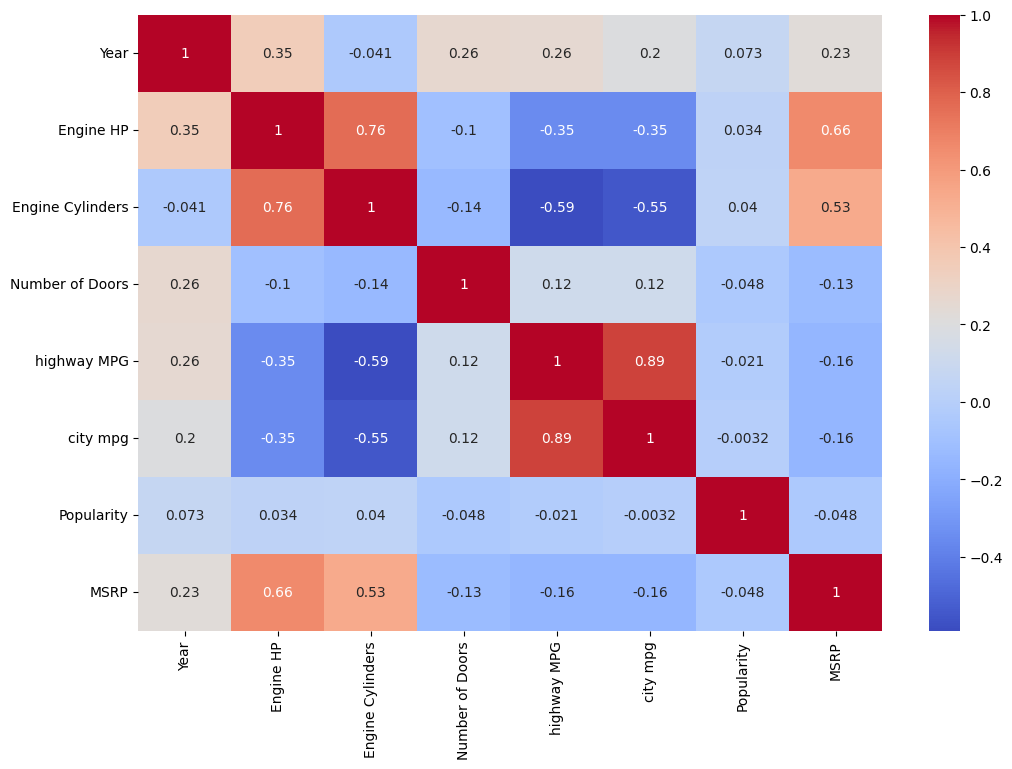

In [14]:
plt.figure(figsize=(12,8))

sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap="coolwarm")

plt.show()

Interpretasi:

Berdasarkan heatmap korelasi, terdapat beberapa hubungan antar variabel. Engine HP memiliki hubungan positif yang cukup kuat dengan MSRP (0,66), yang berarti semakin besar tenaga mesin, harga mobil cenderung semakin tinggi. Engine Cylinders juga memiliki hubungan positif dengan MSRP (0,53), sehingga jumlah silinder yang lebih banyak umumnya diikuti harga mobil yang lebih tinggi. Selain itu, highway MPG dan city mpg memiliki korelasi sangat kuat (0,89), yang menunjukkan bahwa konsumsi bahan bakar di jalan tol dan di dalam kota saling berkaitan.

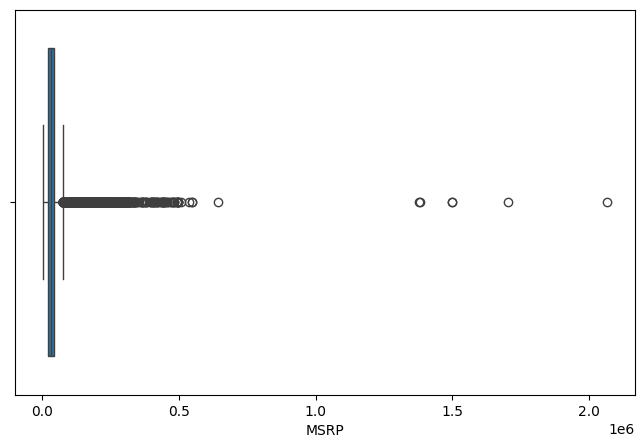

In [36]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["MSRP"])
plt.show()

Interpretasi:

Berdasarkan boxplot, terlihat terdapat beberapa outlier, yaitu data harga mobil yang jauh lebih tinggi dibandingkan sebagian besar data lainnya. Hal ini menunjukkan bahwa dataset memiliki beberapa mobil dengan harga yang sangat mahal, sedangkan mayoritas mobil memiliki harga yang lebih rendah.

In [37]:
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col].astype(str))

Interpretasi:

Data yang bertipe teks, seperti Make, Model, dan Transmission Type, diubah menjadi bentuk angka menggunakan Label Encoding. Hal ini dilakukan karena algoritma regresi hanya dapat mengolah data numerik.

In [38]:
X = df.drop("MSRP", axis=1)

y = df["MSRP"]

Interpretasi:

Pada tahap ini, kolom MSRP dipilih sebagai variabel target (y) yang akan diprediksi, sedangkan seluruh kolom lainnya digunakan sebagai variabel input atau fitur (X).

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Interpretasi:

Dataset dibagi menjadi 80% data training dan 20% data testing. Data training digunakan untuk melatih model, sedangkan data testing digunakan untuk menguji performa model dalam melakukan prediksi.

**MODEL 1**

In [19]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

Interpretasi:

Model Linear Regression dibangun menggunakan data training untuk mempelajari hubungan antara fitur kendaraan dengan harga mobil. Setelah model selesai dilatih, dilakukan prediksi harga mobil pada data testing.

**MODEL 2**

In [41]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

Interpretasi:

Model Decision Tree Regressor dibangun dengan membuat pohon keputusan berdasarkan data training. Model ini kemudian digunakan untuk memprediksi harga mobil pada data testing.

**MODEL** **3**

In [42]:
rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

Interpretasi:

Model Random Forest Regressor dibangun dengan menggabungkan banyak pohon keputusan sehingga menghasilkan prediksi yang lebih stabil dan akurat. Model ini kemudian digunakan untuk memprediksi harga mobil pada data testing.

**EVALUASI**



In [43]:
def evaluasi(nama, y_test, pred):

    print("="*40)
    print(nama)

    print("MAE  :", mean_absolute_error(y_test,pred))
    print("RMSE :", np.sqrt(mean_squared_error(y_test,pred)))
    print("R2   :", r2_score(y_test,pred))

evaluasi("Linear Regression", y_test, pred_lr)

evaluasi("Decision Tree", y_test, pred_dt)

evaluasi("Random Forest", y_test, pred_rf)

Linear Regression
MAE  : 19754.61073317007
RMSE : 31432.019691421967
R2   : 0.5855075073435778
Decision Tree
MAE  : 3193.324585402009
RMSE : 8900.153795806626
R2   : 0.9667671860705971
Random Forest
MAE  : 3029.1657617023557
RMSE : 7187.414717288194
R2   : 0.9783270762845353


Interpretasi:

Berdasarkan hasil evaluasi, Linear Regression memiliki performa paling rendah. Decision Tree memberikan hasil yang lebih baik, sedangkan Random Forest menjadi model terbaik karena memiliki nilai MAE dan RMSE paling kecil serta R² paling tinggi (0,9783).

**PERBANDINGAN MODEL**

In [44]:
hasil = pd.DataFrame({
    "Model":["Linear Regression","Decision Tree","Random Forest"],
    "MAE":[
        mean_absolute_error(y_test,pred_lr),
        mean_absolute_error(y_test,pred_dt),
        mean_absolute_error(y_test,pred_rf)
    ],
    "RMSE":[
        np.sqrt(mean_squared_error(y_test,pred_lr)),
        np.sqrt(mean_squared_error(y_test,pred_dt)),
        np.sqrt(mean_squared_error(y_test,pred_rf))
    ],
    "R2":[
        r2_score(y_test,pred_lr),
        r2_score(y_test,pred_dt),
        r2_score(y_test,pred_rf)
    ]
})

hasil

,Model,MAE,RMSE,R2
0,Linear Regression,19754.610733,31432.019691,0.585508
1,Decision Tree,3193.324585,8900.153796,0.966767
2,Random Forest,3029.165762,7187.414717,0.978327


Interpretasi:

Berdasarkan hasil perbandingan, Random Forest memiliki performa terbaik karena memperoleh MAE (3.029,17) dan RMSE (7.187,41) paling rendah serta R² (0,9783) paling tinggi. Decision Tree juga memberikan hasil yang baik, sedangkan Linear Regression memiliki performa paling rendah dengan nilai kesalahan yang lebih besar dan nilai R² paling kecil.

**KESIMPULAN**

Berdasarkan hasil analisis, dilakukan proses preprocessing untuk menangani missing value menggunakan metode forward fill (ffill) serta mengubah data kategorikal menjadi numerik dengan Label Encoding. Selanjutnya, dilakukan pemodelan menggunakan tiga algoritma regresi, yaitu Linear Regression, Decision Tree Regressor, dan Random Forest Regressor.

Hasil evaluasi menunjukkan bahwa Random Forest Regressor merupakan model terbaik dengan nilai MAE sebesar 3.029,17, RMSE sebesar 7.187,41, dan R² sebesar 0,9783. Nilai tersebut menunjukkan bahwa Random Forest mampu memberikan prediksi harga mobil dengan tingkat kesalahan paling kecil dan akurasi paling tinggi dibandingkan dua model lainnya. Oleh karena itu, Random Forest dipilih sebagai model yang paling sesuai untuk memprediksi harga mobil pada dataset ini.